# GCaMP reference

Flna23
원래 행 수: 2137
NaN 개수:
Wavelength    0
Intensity     2
dtype: int64
정리 후 행 수: 2135
   Wavelength  Intensity
0     155.485     -13.03
1     155.876     -12.91
2     156.266     -12.91
3     156.656     -13.03
4     157.046     -13.03



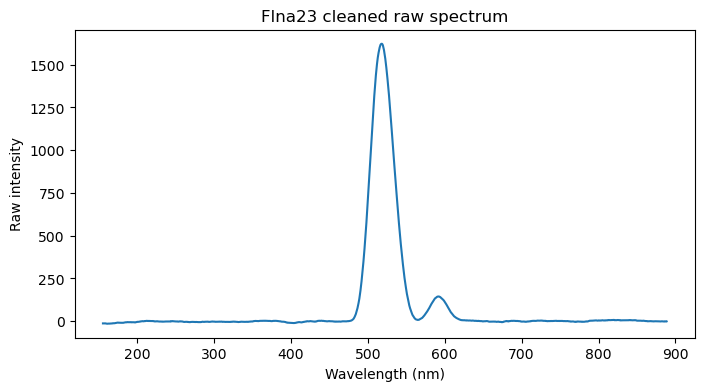

Flna24
원래 행 수: 2136
NaN 개수:
Wavelength    0
Intensity     0
dtype: int64
정리 후 행 수: 2136
   Wavelength  Intensity
0     155.485      -1.26
1     155.876      -1.22
2     156.266      -1.03
3     156.656      -0.88
4     157.046      -0.37



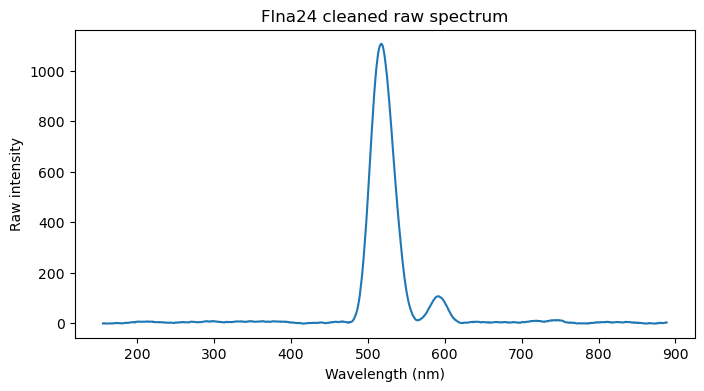

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

files = {

    "Flna23": "/Users/rnlghdb/NDL/data/GCaMP_spectrum/Flna23_GC_gr25uw.csv",

    "Flna24": "/Users/rnlghdb/NDL/data/GCaMP_spectrum/Flna24_GC_gr25uw.csv"

}

clean_refs = {}

for name, path in files.items():

    df = pd.read_csv(path)

    df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")

    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")

    print(name)

    print("원래 행 수:", len(df))

    print("NaN 개수:")

    print(df.isna().sum())

    df = df.dropna().reset_index(drop=True)

    print("정리 후 행 수:", len(df))

    print(df.head())

    print()

    clean_refs[name] = df

    plt.figure(figsize=(8,4))

    plt.plot(df["Wavelength"], df["Intensity"])

    plt.xlabel("Wavelength (nm)")

    plt.ylabel("Raw intensity")

    plt.title(f"{name} cleaned raw spectrum")

    plt.show()

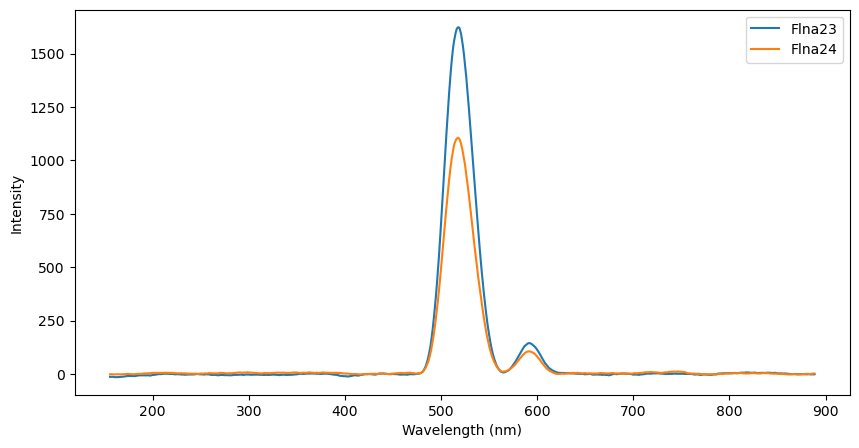

In [3]:
plt.figure(figsize=(10,5))

for name, df in clean_refs.items():

    plt.plot(

        df["Wavelength"],

        df["Intensity"],

        label=name

    )

plt.xlabel("Wavelength (nm)")

plt.ylabel("Intensity")

plt.legend()

plt.show()

peak λ : intensity 가 가장 큰 파장 값 \
peak intensity

In [4]:
for name, df in clean_refs.items():

    idx = df["Intensity"].idxmax()

    print(name)
    print("peak λ =", df.loc[idx, "Wavelength"])
    print("peak intensity =", df.loc[idx, "Intensity"])
    print()

Flna23
peak λ = 517.785
peak intensity = 1623.03

Flna24
peak λ = 517.435
peak intensity = 1106.2



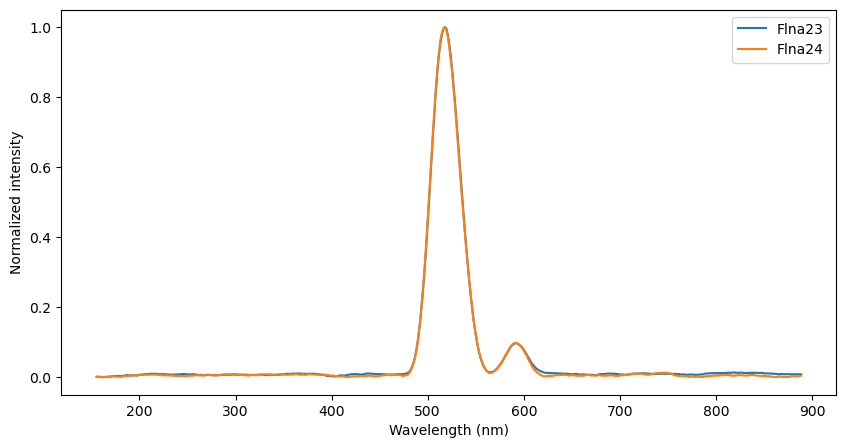

In [5]:
plt.figure(figsize=(10,5))

for name, df in clean_refs.items():

    y = df["Intensity"].values
    y = y - y.min()
    y = y / y.max()

    plt.plot(
        df["Wavelength"],
        y,
        label=name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.show()

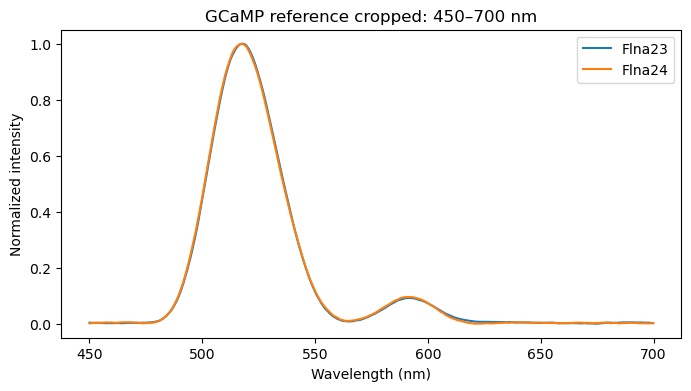

In [6]:
plt.figure(figsize=(8,4))

for name, df in clean_refs.items():
    cropped = df[
        (df["Wavelength"] >= 450) &
        (df["Wavelength"] <= 700)
    ]

    y = cropped["Intensity"].values
    y = y - y.min()
    y = y / y.max()

    plt.plot(cropped["Wavelength"], y, label=name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.title("GCaMP reference cropped: 450–700 nm")
plt.legend()
plt.show()

# jRGECO reference

jRGECO_1
원래 행 수: 2136
NaN 개수:
Wavelength    0
Intensity     0
dtype: int64
정리 후 행 수: 2136
   Wavelength  Intensity
0     155.485       2.35
1     155.876       1.75
2     156.266       1.06
3     156.656       0.53
4     157.046       1.00



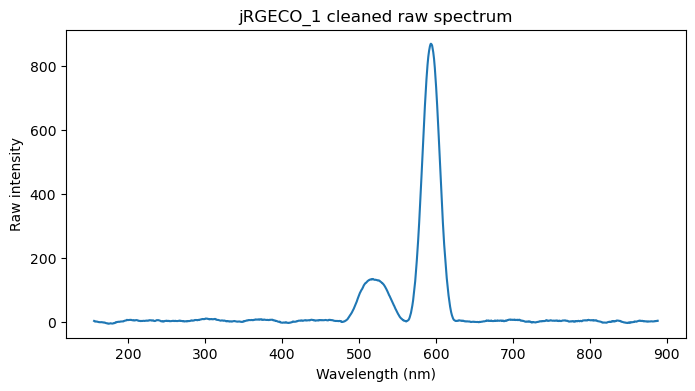

jRGECO_2
원래 행 수: 2136
NaN 개수:
Wavelength    0
Intensity     0
dtype: int64
정리 후 행 수: 2136
   Wavelength  Intensity
0     155.485      -9.06
1     155.876      -8.00
2     156.266      -7.76
3     156.656      -7.91
4     157.046      -8.17



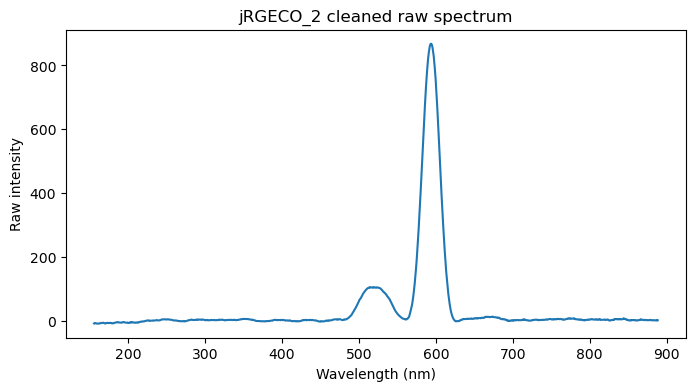

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

files_jrgeco = {
    "jRGECO_1": "/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna17_jR_gr25uw.csv",
    "jRGECO_2": "/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna18_jR_gr25uw.csv"
}

clean_jrgeco_refs = {}

for name, path in files_jrgeco.items():
    df = pd.read_csv(path)

    df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")

    print(name)
    print("원래 행 수:", len(df))
    print("NaN 개수:")
    print(df.isna().sum())

    df = df.dropna().reset_index(drop=True)

    print("정리 후 행 수:", len(df))
    print(df.head())
    print()

    clean_jrgeco_refs[name] = df

    plt.figure(figsize=(8,4))
    plt.plot(df["Wavelength"], df["Intensity"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Raw intensity")
    plt.title(f"{name} cleaned raw spectrum")
    plt.show()

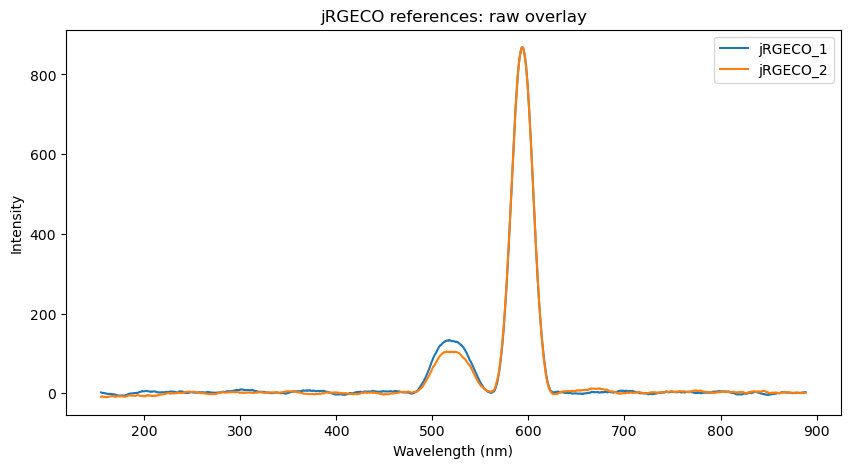

In [14]:
plt.figure(figsize=(10,5))

for name, df in clean_jrgeco_refs.items():
    plt.plot(df["Wavelength"], df["Intensity"], label=name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("jRGECO references: raw overlay")
plt.legend()
plt.show()

In [15]:
for name, df in clean_jrgeco_refs.items():

    idx = df["Intensity"].idxmax()

    print(name)

    print("peak λ =", df.loc[idx, "Wavelength"])

    print("peak intensity =", df.loc[idx, "Intensity"])

    print()

jRGECO_1
peak λ = 593.563
peak intensity = 868.16

jRGECO_2
peak λ = 593.563
peak intensity = 868.16



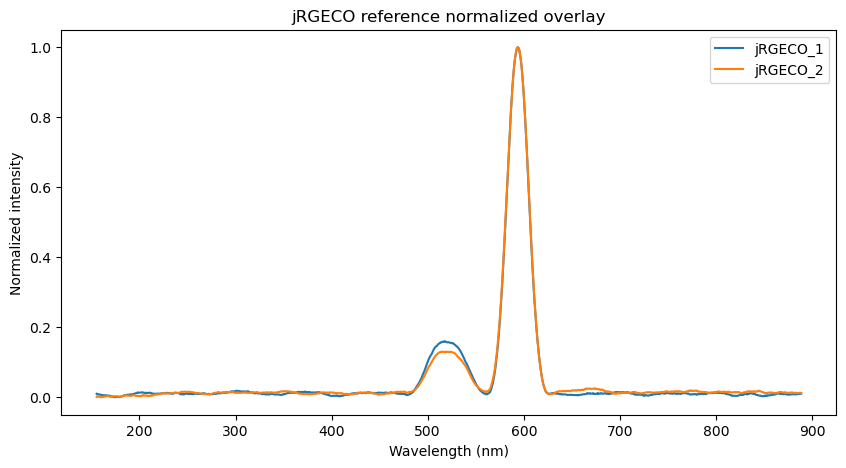

In [16]:
plt.figure(figsize=(10,5))

for name, df in clean_jrgeco_refs.items():
    y = df["Intensity"].values
    y = y - y.min()
    y = y / y.max()

    plt.plot(df["Wavelength"], y, label=name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.title("jRGECO reference normalized overlay")
plt.legend()
plt.show()

In [17]:
for name, path in files_jrgeco.items():
    print(name)
    print(path)
    print()

jRGECO_1
/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna17_jR_gr25uw.csv

jRGECO_2
/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna18_jR_gr25uw.csv



In [18]:
for name, df in clean_jrgeco_refs.items():

    idx = df["Intensity"].idxmax()

    print(name)

    print("index =", idx)

    print("peak λ =", df.loc[idx, "Wavelength"])

    print("peak intensity =", df.loc[idx, "Intensity"])

    print()

jRGECO_1
index = 1197
peak λ = 593.563
peak intensity = 868.16

jRGECO_2
index = 1197
peak λ = 593.563
peak intensity = 868.16



In [19]:
print(clean_jrgeco_refs["jRGECO_1"].shape)

print(clean_jrgeco_refs["jRGECO_2"].shape)

print(

    clean_jrgeco_refs["jRGECO_1"].equals(

        clean_jrgeco_refs["jRGECO_2"]

    )

)

(2136, 2)
(2136, 2)
False


max abs diff: 30.28
mean abs diff: 4.9862734082397004
diff at peak index 1197: 0.0


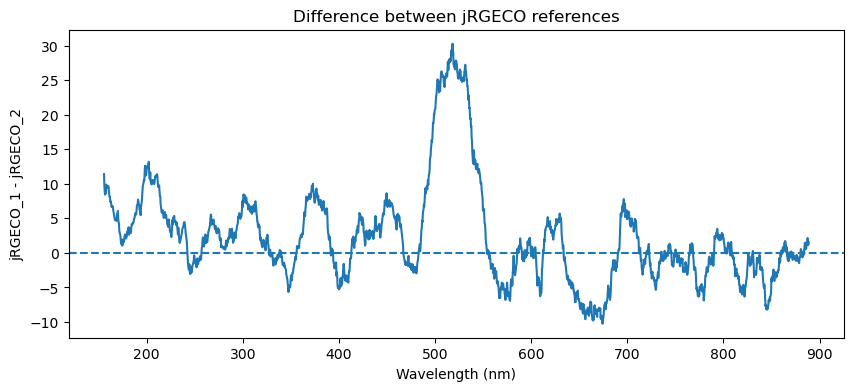

In [20]:
df1 = clean_jrgeco_refs["jRGECO_1"]
df2 = clean_jrgeco_refs["jRGECO_2"]

diff = df1["Intensity"] - df2["Intensity"]

print("max abs diff:", diff.abs().max())
print("mean abs diff:", diff.abs().mean())
print("diff at peak index 1197:", diff.iloc[1197])

plt.figure(figsize=(10,4))
plt.plot(df1["Wavelength"], diff)
plt.axhline(0, linestyle="--")
plt.xlabel("Wavelength (nm)")
plt.ylabel("jRGECO_1 - jRGECO_2")
plt.title("Difference between jRGECO references")
plt.show()

# reference 파일 생성

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 저장 경로
output_dir = "/Users/rnlghdb/NDL/data/reference_spectrum"

# reference 파일 경로
gcamp_files = {
    "Flna23": "/Users/rnlghdb/NDL/data/GCaMP_spectrum/Flna23_GC_gr25uw.csv",
    "Flna24": "/Users/rnlghdb/NDL/data/GCaMP_spectrum/Flna24_GC_gr25uw.csv"
}

jrgeco_files = {
    "jRGECO_1": "/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna17_jR_gr25uw.csv",
    "jRGECO_2": "/Users/rnlghdb/NDL/data/jRGECO_spectrum/Flna18_jR_gr25uw.csv"
}

In [22]:
import os
os.makedirs(output_dir, exist_ok=True)

def make_reference(files, output_name, crop_min=450, crop_max=700):
    refs = []

    for name, path in files.items():
        df = pd.read_csv(path)

        df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
        df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
        df = df.dropna().reset_index(drop=True)

        df = df[
            (df["Wavelength"] >= crop_min) &
            (df["Wavelength"] <= crop_max)
        ].reset_index(drop=True)

        y = df["Intensity"].values
        y = y - y.min()
        y = y / y.max()

        refs.append({
            "name": name,
            "wavelength": df["Wavelength"].values,
            "norm": y
        })

    base_wavelength = refs[0]["wavelength"]

    aligned = []
    for ref in refs:
        aligned_y = np.interp(
            base_wavelength,
            ref["wavelength"],
            ref["norm"]
        )
        aligned.append(aligned_y)

    mean_ref = np.mean(aligned, axis=0)

    ref_df = pd.DataFrame({
        "Wavelength": base_wavelength,
        "Reference": mean_ref
    })

    output_path = os.path.join(output_dir, output_name)
    ref_df.to_csv(output_path, index=False)

    plt.figure(figsize=(8,4))
    for ref in aligned:
        plt.plot(base_wavelength, ref, alpha=0.5)

    plt.plot(base_wavelength, mean_ref, linewidth=2, label="mean reference")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized intensity")
    plt.title(output_name)
    plt.legend()
    plt.show()

    print(f"저장 완료: {output_path}")
    print(ref_df.head())

    return ref_df

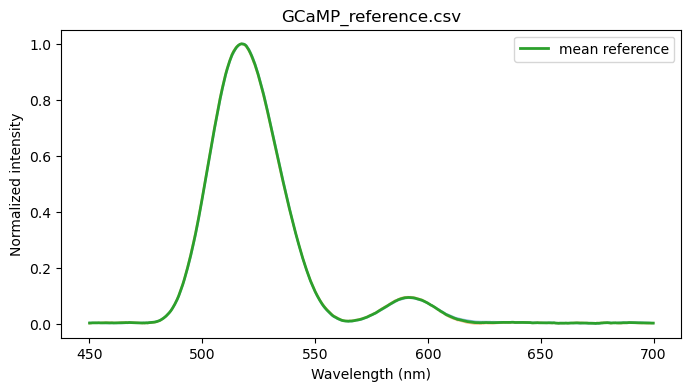

저장 완료: /Users/rnlghdb/NDL/data/reference_spectrum/GCaMP_reference.csv
   Wavelength  Reference
0     450.154   0.002441
1     450.512   0.002494
2     450.870   0.002599
3     451.229   0.003039
4     451.587   0.003027


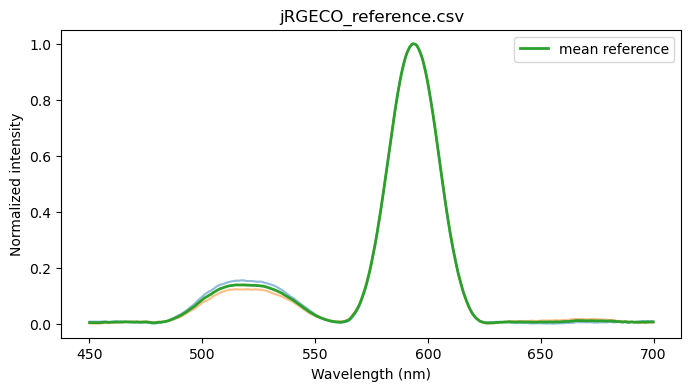

저장 완료: /Users/rnlghdb/NDL/data/reference_spectrum/jRGECO_reference.csv
   Wavelength  Reference
0     450.154   0.004202
1     450.512   0.004207
2     450.870   0.004121
3     451.229   0.004161
4     451.587   0.004156


In [23]:
gcamp_ref = make_reference(
    gcamp_files,
    "GCaMP_reference.csv"
)

jrgeco_ref = make_reference(
    jrgeco_files,
    "jRGECO_reference.csv"
)

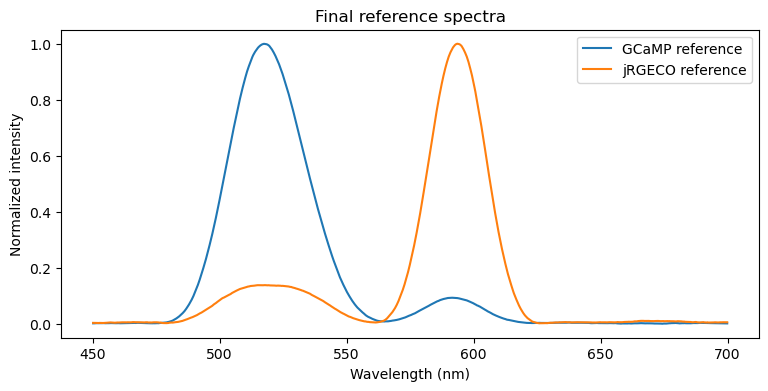

In [24]:
plt.figure(figsize=(9,4))

plt.plot(
    gcamp_ref["Wavelength"],
    gcamp_ref["Reference"],
    label="GCaMP reference"
)

plt.plot(
    jrgeco_ref["Wavelength"],
    jrgeco_ref["Reference"],
    label="jRGECO reference"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.title("Final reference spectra")
plt.legend()
plt.show()

In [25]:
reference_df = pd.DataFrame({
    "Wavelength": gcamp_ref["Wavelength"],
    "GCaMP6f": gcamp_ref["Reference"],
    "jRGECO1a": jrgeco_ref["Reference"]
})

reference_df.to_csv(
    "/Users/rnlghdb/NDL/data/reference_spectrum/reference_matrix.csv",
    index=False
)

In [26]:
reference_df.head(20)

,Wavelength,GCaMP6f,jRGECO1a
0,450.154,0.002441,0.004202
1,450.512,0.002494,0.004207
2,450.870,0.002599,0.004121
3,451.229,0.003039,0.004161
4,451.587,0.003027,0.004156
5,451.945,0.003104,0.003857
6,452.303,0.003163,0.003685
7,452.662,0.003363,0.004052
8,453.020,0.003184,0.003920
9,453.378,0.002843,0.003926


In [27]:
reference_df.describe()

,Wavelength,GCaMP6f,jRGECO1a
count,733.000000,733.000000,733.000000
mean,577.162831,0.154392,0.135638
std,72.249624,0.281401,0.250509
min,450.154000,0.001121,0.002632
25%,514.986000,0.003320,0.006234
50%,578.253000,0.012542,0.013753
75%,639.890000,0.093480,0.128556
max,699.829000,0.999684,1.000000


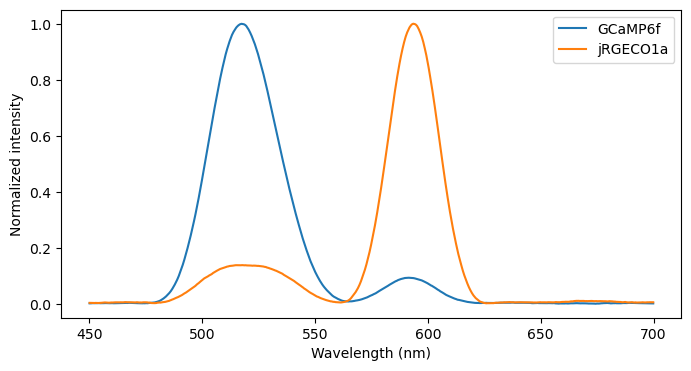

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    reference_df["Wavelength"],
    reference_df["GCaMP6f"],
    label="GCaMP6f"
)

plt.plot(
    reference_df["Wavelength"],
    reference_df["jRGECO1a"],
    label="jRGECO1a"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.show()

In [30]:
reference_df.shape

(733, 3)